In [2]:
import torch
import torch.nn.functional as F
x = torch.randn(2, 5)
print(x)
x_norm=F.normalize(x, dim=-1, eps=1e-3)
print(x_norm)     # 基本全是 1.0

tensor([[ 1.0918, -0.4019, -0.4139,  0.3188,  0.6005],
        [ 0.4871, -0.5999, -1.2833, -1.3520,  0.6679]])
tensor([[ 0.7745, -0.2851, -0.2936,  0.2261,  0.4260],
        [ 0.2292, -0.2822, -0.6038, -0.6361,  0.3142]])


/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


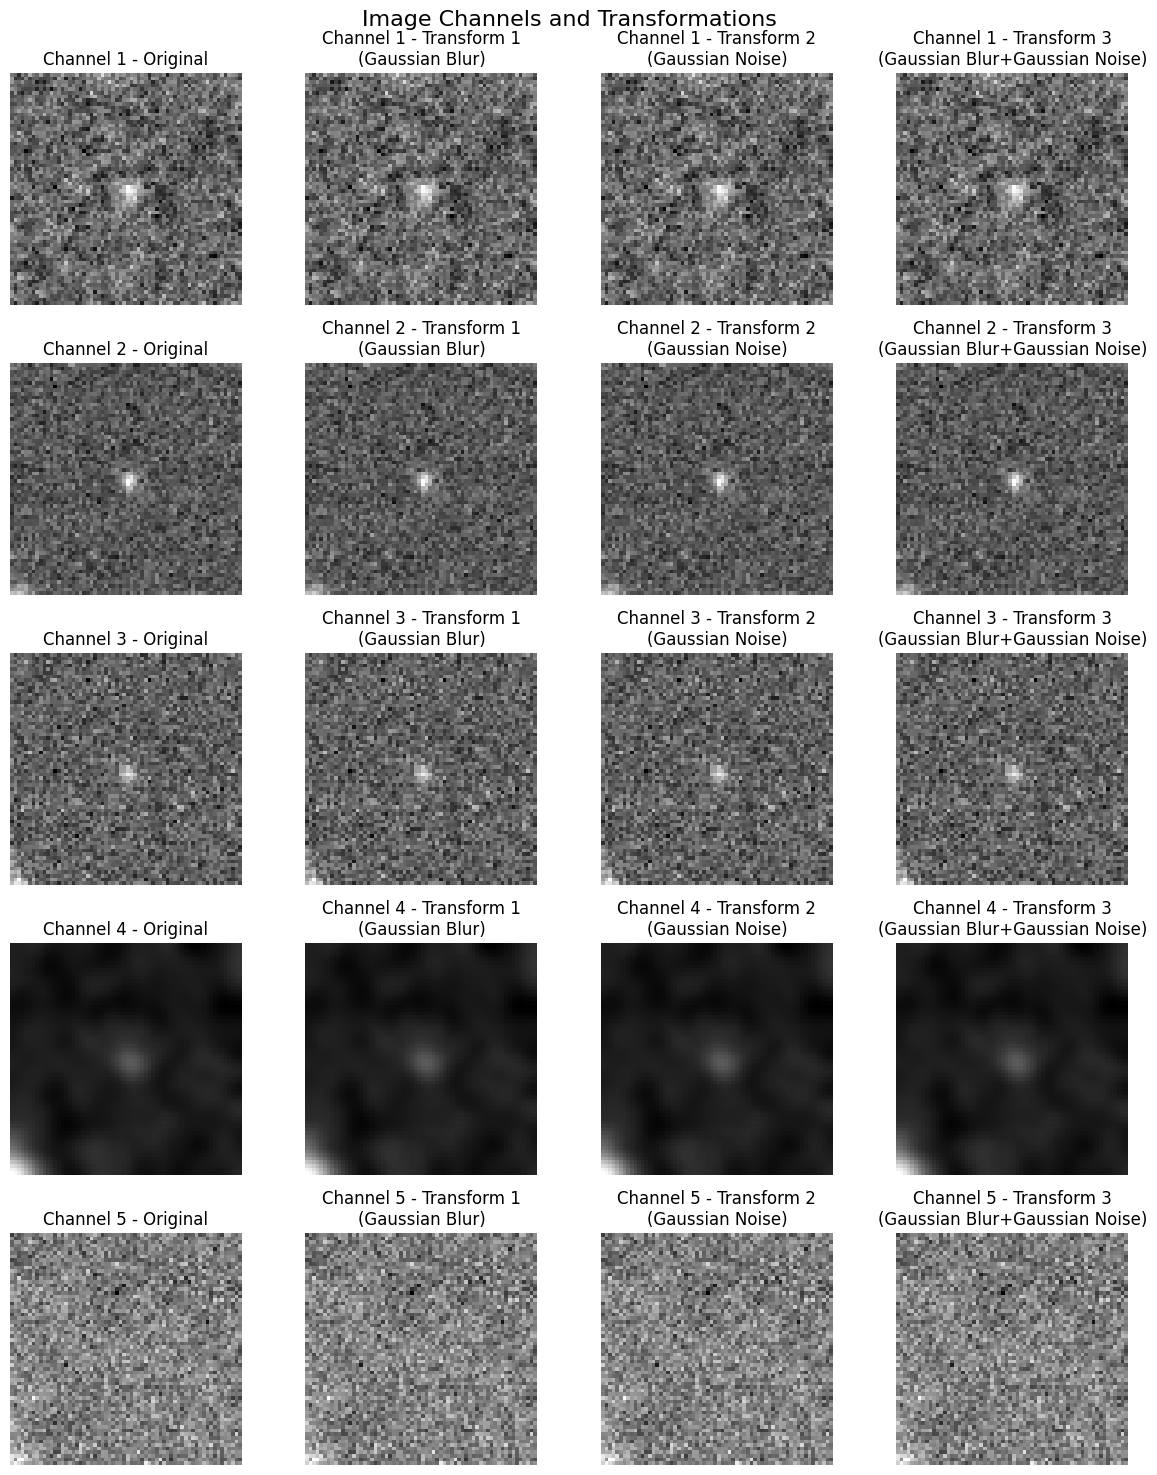

In [1]:
import skimage
from typing import List
from datasets import load_from_disk
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import transforms


class GaussianNoise:
    """
    Augmentations tuned to the Legacy Survey Data (with minor modifications).

    Code copied from
    https://github.com/georgestein/ssl-legacysurvey/blob/main/ssl_legacysurvey/data_loaders/decals_augmentations.py#L296
    """

    def __init__(
        self,
        scaling: List = [1.0],
        mean: float = 0,
        im_dim: int = 144,
        im_ch: int = 5,
        decals: bool = True,
        uniform: bool = False,
    ):
        self.mean = mean
        self.decals = decals
        self.im_ch = im_ch
        self.im_dim = im_dim
        self.uniform = uniform

        # Log normal fit paramaters
        self.shape_dist = np.array(
            [0.1745501011610031, 0.13902300596237183, 0.11488369852304459, 0.13054630160331726, 0.17551860213279724])
        self.loc_dist = np.array([0, 0, 0, 0, 0])
        self.scale_dist = np.array(
            [0.04473619908094406, 0.016824299469590187, 0.026677900925278664, 0.04432990029454231, 0.17248259484767914])

        self.sigma_dist = np.log(self.scale_dist)

        # noise in channels is uncorrelated, as images taken at dirrerent times/telescopes
        self.noise_ch_min = np.array([0.031167, 0.0132974, 0.0216753, 0.0336255, 0.1219355])
        self.noise_ch_max = np.array([0.0696115, 0.024097, 0.0360224, 0.0607057, 0.2605831])

    def __call__(self, image: np.ndarray):
        # draw 'true' noise level of each channel from lognormal fits
        self.sigma_true = (
            np.random.lognormal(self.sigma_dist, self.shape_dist) + self.loc_dist
        )

        if self.uniform:
            # draw desired augmented noise level from uniform, to target tails more
            self.sigma_final = np.random.uniform(self.noise_ch_min, self.noise_ch_max)
        else:
            self.sigma_final = (
                np.random.lognormal(self.sigma_dist, self.shape_dist) + self.loc_dist
            )

        # Gaussian noise adds as c^2 = a^2 + b^2
        self.sigma_augment = self.sigma_final**2 - self.sigma_true**2
        self.sigma_augment[self.sigma_augment < 0.0] = 0.0
        self.sigma_augment = np.sqrt(self.sigma_augment)

        for i in range(self.im_ch):
            if self.sigma_augment[i] > 0.0:
                image[i, :, :] += np.random.normal(
                    self.mean, self.sigma_augment[i], size=(self.im_dim, self.im_dim)
                )

        return image


class GaussianBlur:
    """
    Augmentations tuned to the Legacy Survey Data (with minor modifications).

    Code copied from
    https://github.com/georgestein/ssl-legacysurvey/blob/main/ssl_legacysurvey/data_loaders/decals_augmentations.py#L296
    """

    def __init__(
        self,
        scaling: List = [1.0],
        im_dim: int = 144,
        im_ch: int = 5,
        decals: bool = True,
        uniform: bool = False,
    ):
        self.decals = decals
        self.im_ch = im_ch
        self.im_dim = im_dim
        self.uniform = uniform

        # Log normal fit paramaters
        self.shape_dist = np.array([0.3490406, 0.2582798, 0.3337356, 0.4394641, 0.6281115])
        self.loc_dist = np.array([0.752382, 0.7642949, 0.803989, 0.9436479, 1.1158381])
        self.scale_dist = np.array([1.4370568, 1.9462386, 1.6218294, 1.2486718, 0.8676406])

        self.sigma_dist = np.log(self.scale_dist)

        self.psf_ch_min = np.array([1.3959353, 1.8118689, 1.5144078, 1.3738828, 1.3474936])
        self.psf_ch_max = np.array([4.1464071, 4.6310138, 4.7327875, 4.7048585, 4.4890077])

    def __call__(self, image: np.ndarray):
        # noise in channels is uncorrelated, as images taken at different times/telescopes
        # draw 'true' noise level of each channel from lognormal fits
        self.sigma_true = (
            np.random.lognormal(self.sigma_dist, self.shape_dist) + self.loc_dist
        )

        if self.uniform:
            # draw desired augmented noise level from uniform, to target tails more
            self.sigma_final = np.random.uniform(self.psf_ch_min, self.psf_ch_max)
        else:
            self.sigma_final = (
                np.random.lognormal(self.sigma_dist, self.shape_dist) + self.loc_dist
            )

        # Gaussian noise adds as c^2 = a^2 + b^2
        self.sigma_augment = self.sigma_final**2 - self.sigma_true**2
        self.sigma_augment[self.sigma_augment < 0.0] = 0.0
        self.sigma_augment = np.sqrt(self.sigma_augment)

        for i in range(self.im_ch):
            if self.sigma_augment[i] > 0.0:
                image[i, :, :] = skimage.filters.gaussian(
                    image[i, :, :], sigma=self.sigma_augment[i], mode="reflect"
                )

        return image

# 创建示例图像 (5个通道, 64x64)
dset =load_from_disk("/mnt/d/SoftWare/PycharmProjects/data/data_g3_z_1k/train_dataset")
# img = dset.shuffle().select(range(1))["image"][0].numpy()
img = dset["image"][0].numpy()
# 定义三个变换函数
def transform1(image):
    """高斯噪声增强"""
    trans=GaussianBlur()
    return trans(image)

def transform2(image):
    """亮度调整"""
    trans=GaussianNoise(im_dim=64)
    return trans(image)

def transform3(image):
    """对比度调整"""
    trans=transforms.Compose([
        GaussianBlur(),
        GaussianNoise(im_dim=64)
    ])
    return trans(image)

# 创建5行4列的可视化图表
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
fig.suptitle('Image Channels and Transformations', fontsize=16)

original=img
transformed1 = transform1(original)
transformed2 = transform2(original)
transformed3 = transform3(original)

# 对每个通道进行处理和可视化
for channel in range(5):
    # 原始图像
    axes[channel, 0].imshow(original[channel], cmap='gray')
    axes[channel, 0].set_title(f'Channel {channel+1} - Original')
    axes[channel, 0].axis('off')

    # 应用变换1
    axes[channel, 1].imshow(transformed1[channel], cmap='gray')
    axes[channel, 1].set_title(f'Channel {channel+1} - Transform 1\n(Gaussian Blur)')
    axes[channel, 1].axis('off')

    # 应用变换2
    axes[channel, 2].imshow(transformed2[channel], cmap='gray')
    axes[channel, 2].set_title(f'Channel {channel+1} - Transform 2\n(Gaussian Noise)')
    axes[channel, 2].axis('off')

    # 应用变换3
    axes[channel, 3].imshow(transformed3[channel], cmap='gray')
    axes[channel, 3].set_title(f'Channel {channel+1} - Transform 3\n(Gaussian Blur+Gaussian Noise)')
    axes[channel, 3].axis('off')

plt.tight_layout()
plt.show()


In [1]:
import datasets
test=datasets.load_from_disk("/mnt/d/SoftWare/PycharmProjects/data/data_g3_z_1k/test_dataset")
params=[i for i in test["params"]]

/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
def plot_single_feature_distributions(params):
    feature_names = [
        'psfMag_u', 'psfMag_g', 'psfMag_r', 'psfMag_i', 'psfMag_z',
        'extinction_u', 'extinction_g', 'extinction_r', 'extinction_i', 'extinction_z',
        'psfMagErr_u', 'psfMagErr_g', 'psfMagErr_r', 'psfMagErr_i', 'psfMagErr_z'
    ]

    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()

    for i in range(15):
        axes[i].hist(params[:, i], bins=50, alpha=0.7, color=f'C{i%10}')
        axes[i].set_title(feature_names[i])
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

def calculate_color_indices(params):
    """
    计算指定的色指数 (magnitude differences between adjacent bands)
    只计算: u-g, g-r, r-i, i-z
    """
    # 确保 params 是 numpy 数组
    if not isinstance(params, np.ndarray):
        params = np.array(params)

    psf_mags = params[:, :5]  # psfMag_u to psfMag_z
    colors = []
    color_names = []

    # 只计算相邻波段的色指数
    band_names = ['u', 'g', 'r', 'i', 'z']
    adjacent_pairs = [(0, 1), (1, 2), (2, 3), (3, 4)]  # u-g, g-r, r-i, i-z

    for i, j in adjacent_pairs:
        color_index = psf_mags[:, i] - psf_mags[:, j]
        colors.append(color_index)
        color_names.append(f'{band_names[i]}-{band_names[j]}')

    return np.column_stack(colors), color_names

def plot_color_distributions(params):
    """
    绘制指定色指数的分布直方图
    """
    # 确保 params 是 numpy 数组
    if not isinstance(params, np.ndarray):
        params = np.array(params)

    colors, color_names = calculate_color_indices(params)

    # 创建 2x2 子图布局，因为只有 4 个色指数
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i in range(len(color_names)):
        axes[i].hist(colors[:, i], bins=50, alpha=0.7, color=f'C{i%10}')
        axes[i].set_title(f'Color Index: {color_names[i]}')
        axes[i].set_xlabel('Magnitude Difference')
        axes[i].set_ylabel('Frequency')
        axes[i].axvline(np.mean(colors[:, i]), color='red', linestyle='--',
                       label=f'Mean: {np.mean(colors[:, i]):.2f}')
        axes[i].legend()

    # 隐藏多余的子图（如果有）
    for i in range(len(color_names), 4):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

def visualize_quasar_photometry(params):
    """
    完整的类星体测光数据可视化
    """
    # 1. 原始特征分布
    plot_single_feature_distributions(params)

    # 2. 色指数分布
    plot_color_distributions(params)

    # 3. 综合统计信息
    print("数据集统计信息:")
    print(f"样本数量: {params.shape[0]}")
    print(f"特征数量: {params.shape[1]}")

    # 显示各特征的基本统计信息
    feature_names = [
        'psfMag_u', 'psfMag_g', 'psfMag_r', 'psfMag_i', 'psfMag_z',
        'extinction_u', 'extinction_g', 'extinction_r', 'extinction_i', 'extinction_z',
        'psfMagErr_u', 'psfMagErr_g', 'psfMagErr_r', 'psfMagErr_i', 'psfMagErr_z'
    ]

    for i, name in enumerate(feature_names):
        print(f"{name}: mean={np.mean(params[:, i]):.3f}, "
              f"std={np.std(params[:, i]):.3f}, "
              f"min={np.min(params[:, i]):.3f}, "
              f"max={np.max(params[:, i]):.3f}")

# 使用示例



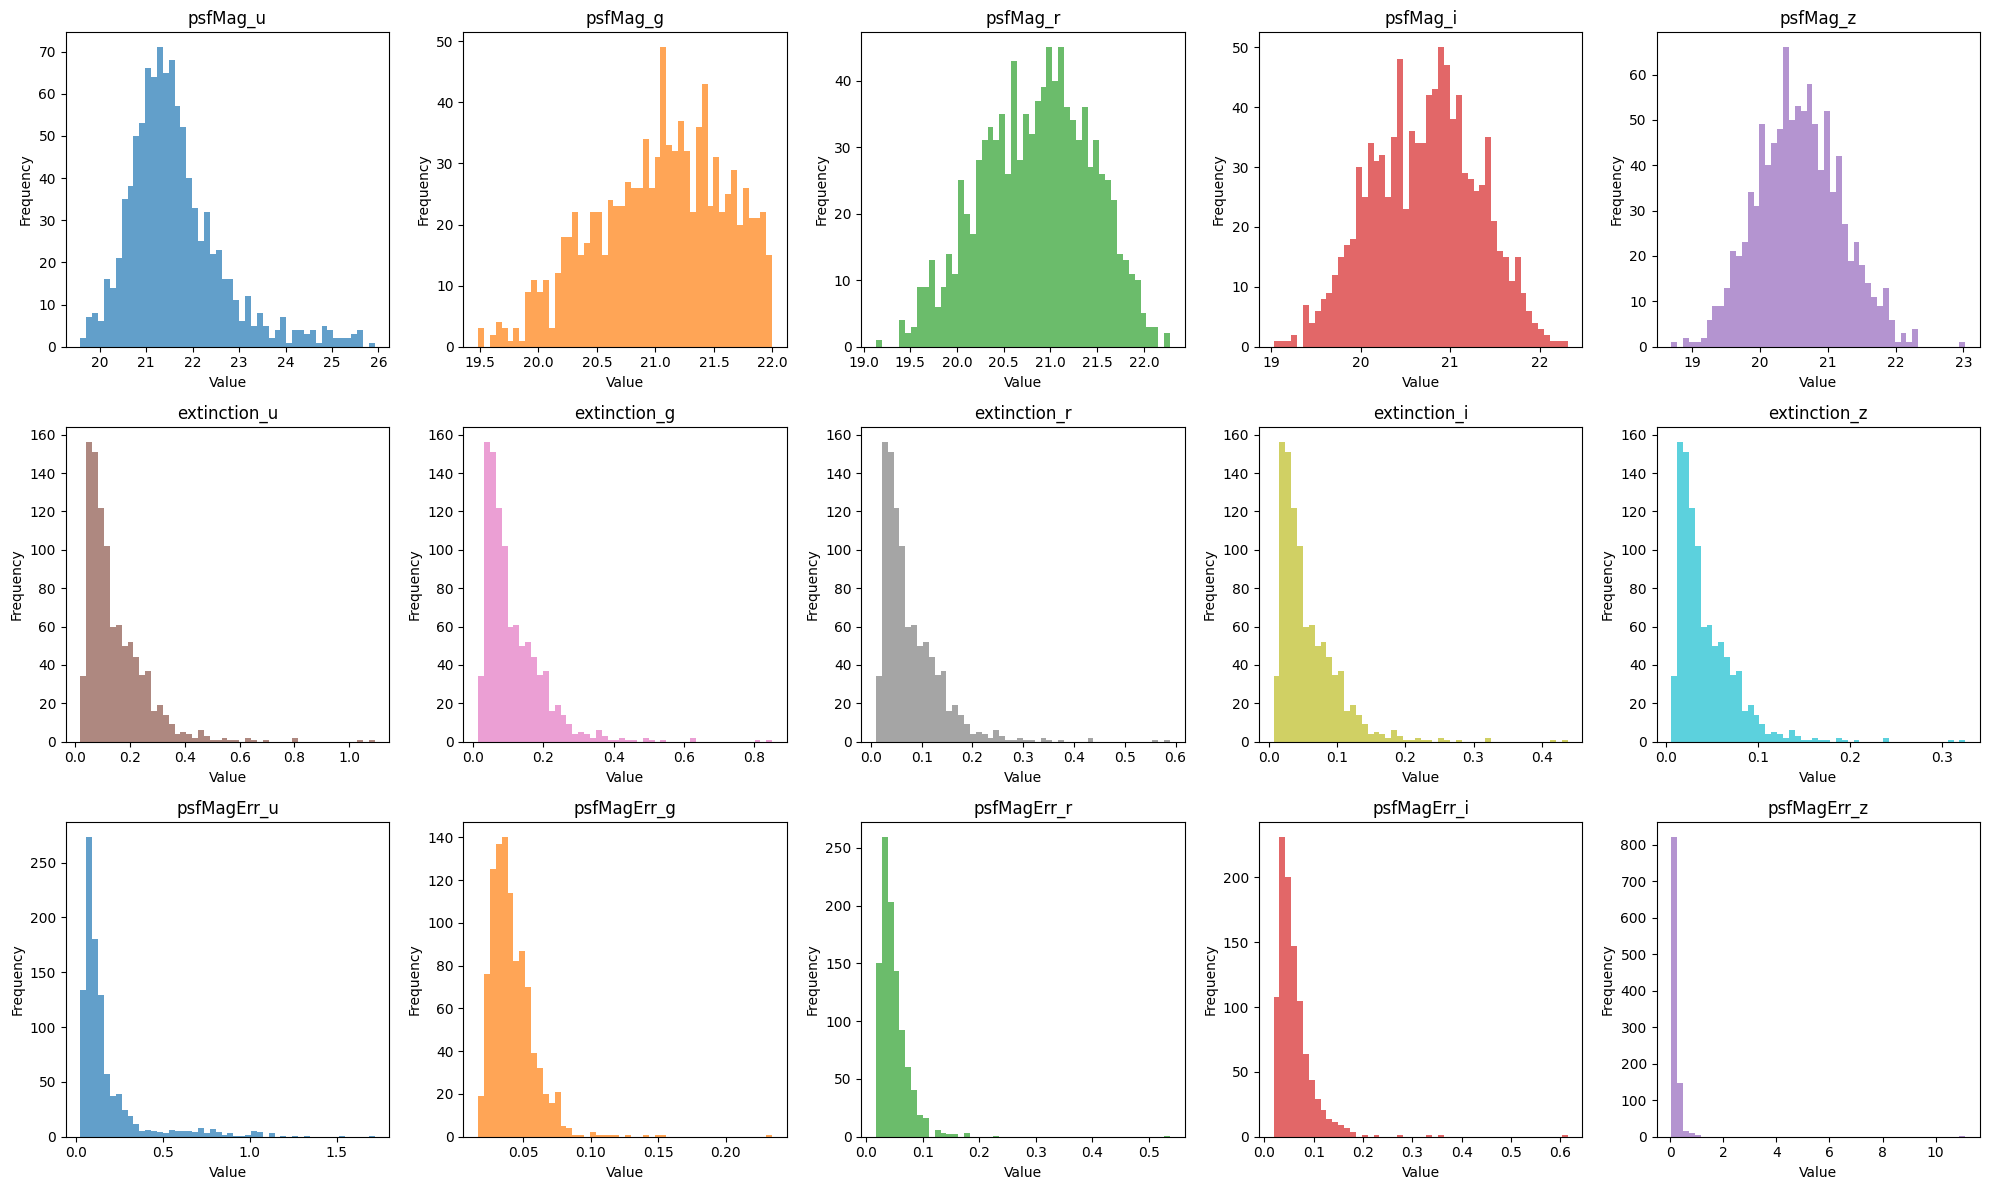

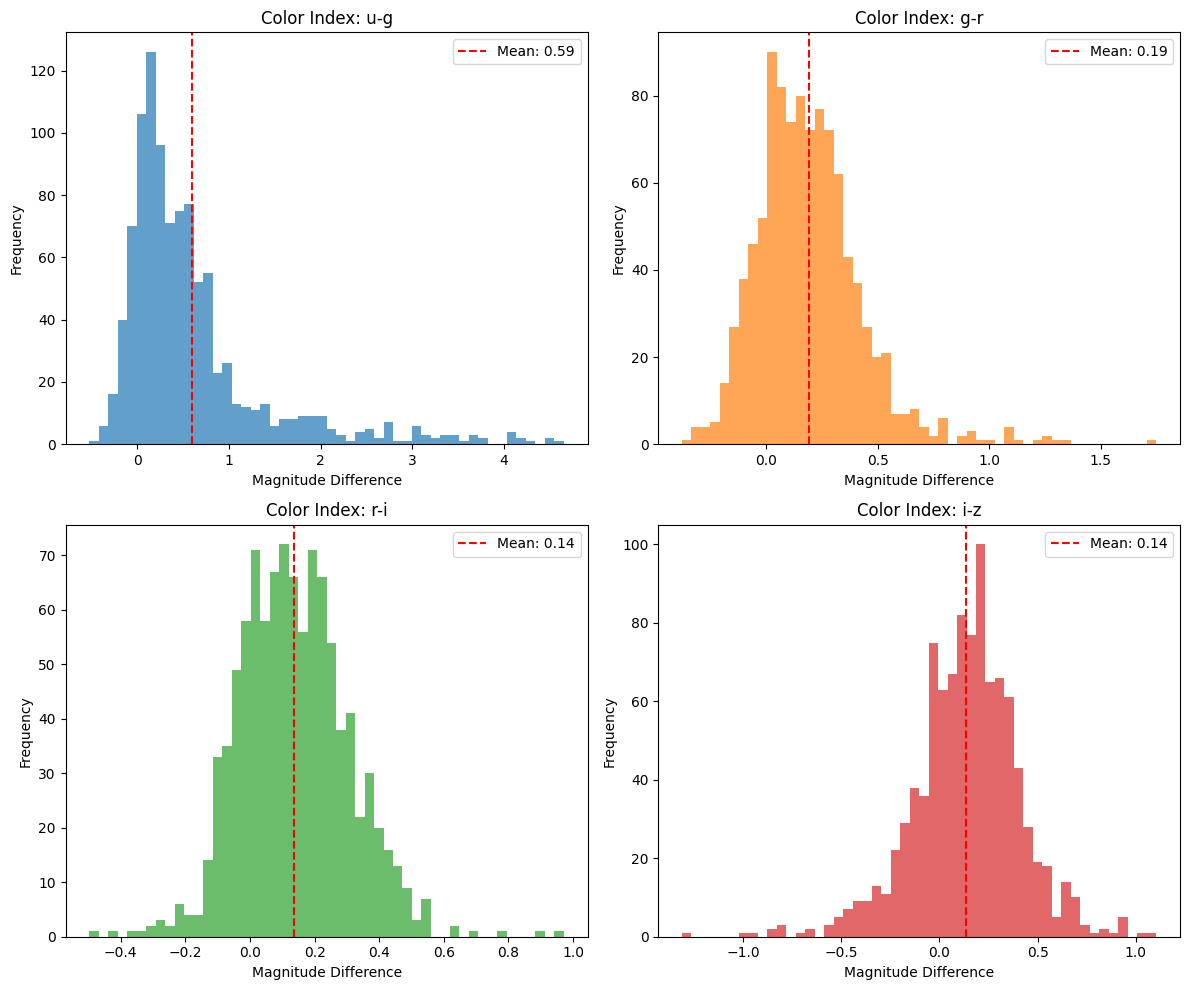

数据集统计信息:
样本数量: 1000
特征数量: 15
psfMag_u: mean=21.635, std=1.035, min=19.585, max=25.917
psfMag_g: mean=21.041, std=0.550, min=19.485, max=21.998
psfMag_r: mean=20.852, std=0.582, min=19.132, max=22.278
psfMag_i: mean=20.714, std=0.589, min=19.025, max=22.311
psfMag_z: mean=20.579, std=0.617, min=18.697, max=23.027
extinction_u: mean=0.146, std=0.112, min=0.018, max=1.093
extinction_g: mean=0.114, std=0.087, min=0.014, max=0.851
extinction_r: mean=0.079, std=0.060, min=0.010, max=0.589
extinction_i: mean=0.058, std=0.045, min=0.007, max=0.438
extinction_z: mean=0.043, std=0.033, min=0.005, max=0.326
psfMagErr_u: mean=0.182, std=0.208, min=0.028, max=1.717
psfMagErr_g: mean=0.042, std=0.017, min=0.017, max=0.234
psfMagErr_r: mean=0.048, std=0.028, min=0.017, max=0.537
psfMagErr_i: mean=0.061, std=0.038, min=0.018, max=0.615
psfMagErr_z: mean=0.202, std=0.370, min=0.039, max=11.118


In [18]:
import numpy as np
params=np.array(params)
visualize_quasar_photometry(params)

In [21]:
def apply_extinction_correction(params):
    """
    对星等进行消光处理
    消光修正公式: mag_corrected = mag_observed - extinction
    """

    # 提取观测星等和消光系数
    psf_mags = params[:, :5]        # psfMag_u, psfMag_g, psfMag_r, psfMag_i, psfMag_z
    extinctions = params[:, 5:10]   # extinction_u, extinction_g, extinction_r, extinction_i, extinction_z

    # 进行消光修正
    corrected_mags = psf_mags - extinctions

    return corrected_mags

def plot_corrected_magnitudes(params):
    """
    可视化消光后的星等分布
    """


    # 获取消光修正后的星等
    corrected_mags = apply_extinction_correction(params)

    # 特征名称
    band_names = ['u', 'g', 'r', 'i', 'z']
    feature_names = [f'corrected_psfMag_{band}' for band in band_names]

    # 绘制直方图
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes = axes.flatten()

    for i in range(5):
        axes[i].hist(corrected_mags[:, i], bins=50, alpha=0.7, color=f'C{i}')
        axes[i].set_title(feature_names[i])
        axes[i].set_xlabel('Magnitude')
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

def calculate_corrected_color_indices(params):
    """
    使用消光修正后的星等计算色指数
    只计算: u-g, g-r, r-i, i-z
    """


    # 获取消光修正后的星等
    corrected_mags = apply_extinction_correction(params)

    colors = []
    color_names = []

    # 计算相邻波段的色指数
    band_names = ['u', 'g', 'r', 'i', 'z']
    adjacent_pairs = [(0, 1), (1, 2), (2, 3), (3, 4)]  # u-g, g-r, r-i, i-z

    for i, j in adjacent_pairs:
        color_index = corrected_mags[:, i] - corrected_mags[:, j]
        colors.append(color_index)
        color_names.append(f'{band_names[i]}-{band_names[j]}')

    return np.column_stack(colors), color_names

def plot_corrected_color_distributions(params):
    """
    绘制消光修正后色指数的分布直方图
    """


    colors, color_names = calculate_corrected_color_indices(params)

    # 创建 2x2 子图布局
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i in range(len(color_names)):
        axes[i].hist(colors[:, i], bins=50, alpha=0.7, color=f'C{i}')
        axes[i].set_title(f'Corrected Color Index: {color_names[i]}')
        axes[i].set_xlabel('Magnitude Difference')
        axes[i].set_ylabel('Frequency')
        axes[i].axvline(np.mean(colors[:, i]), color='red', linestyle='--',
                       label=f'Mean: {np.mean(colors[:, i]):.2f}')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

def visualize_extinction_corrected_photometry(params):
    """
    完整的消光修正后测光数据可视化
    """


    print("=== 消光修正后的数据可视化 ===")

    # 1. 消光修正后星等分布
    print("1. 绘制消光修正后的星等分布...")
    plot_corrected_magnitudes(params)

    # 2. 消光修正后色指数分布
    print("2. 绘制消光修正后的色指数分布...")
    plot_corrected_color_distributions(params)

    # 3. 统计信息
    corrected_mags = apply_extinction_correction(params)
    corrected_colors, color_names = calculate_corrected_color_indices(params)

    print("\n消光修正后星等统计信息:")
    band_names = ['u', 'g', 'r', 'i', 'z']
    for i, band in enumerate(band_names):
        print(f"corrected_psfMag_{band}: mean={np.mean(corrected_mags[:, i]):.3f}, "
              f"std={np.std(corrected_mags[:, i]):.3f}")

    print("\n消光修正后色指数统计信息:")
    for i, name in enumerate(color_names):
        print(f"{name}: mean={np.mean(corrected_colors[:, i]):.3f}, "
              f"std={np.std(corrected_colors[:, i]):.3f}")

=== 消光修正后的数据可视化 ===
1. 绘制消光修正后的星等分布...


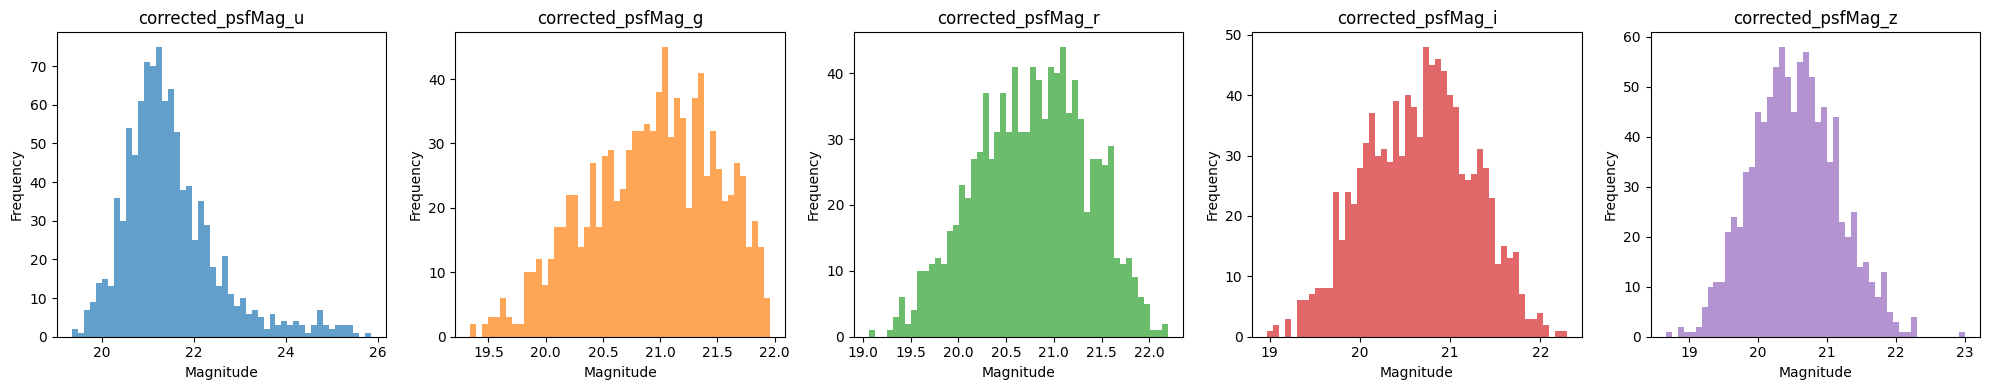

2. 绘制消光修正后的色指数分布...


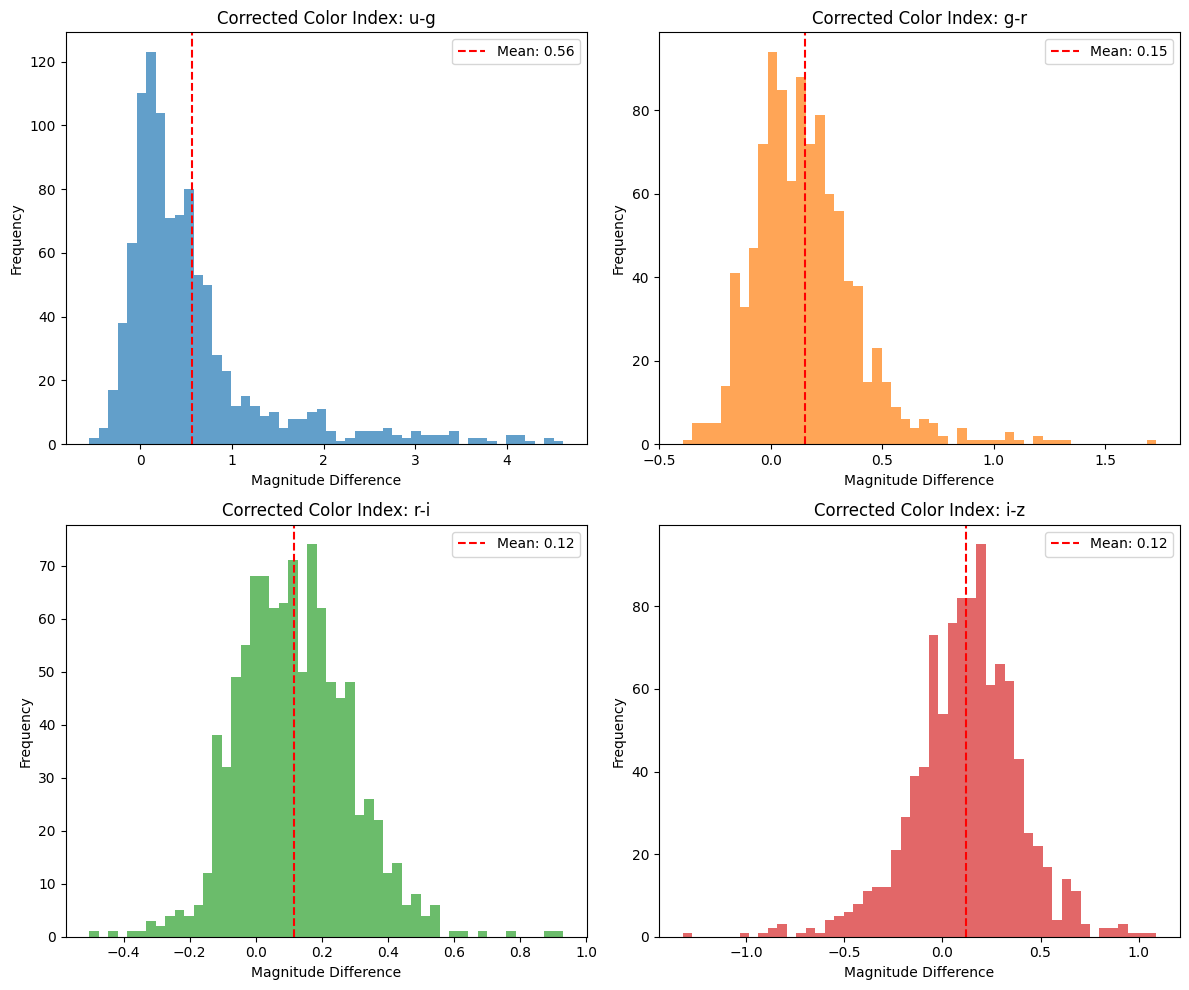


消光修正后星等统计信息:
corrected_psfMag_u: mean=21.489, std=1.036
corrected_psfMag_g: mean=20.928, std=0.554
corrected_psfMag_r: mean=20.773, std=0.586
corrected_psfMag_i: mean=20.656, std=0.593
corrected_psfMag_z: mean=20.535, std=0.620

消光修正后色指数统计信息:
u-g: mean=0.562, std=0.811
g-r: mean=0.155, std=0.235
r-i: mean=0.117, std=0.168
i-z: mean=0.121, std=0.271


In [22]:
visualize_extinction_corrected_photometry(params)

In [1]:
name="backbone.blocks.5.attn.qkv.weight"

8

In [6]:
name[name.find(".blocks."):].split(".")

['', 'blocks', '5', 'attn', 'qkv', 'weight']

In [2]:
import torch
batch_size=2
cat_cardinalities = [
    4,  # Allowed values: [0, 1, 2, 3].
    7,  # Allowed values: [0, 1, 2, 3, 4, 5, 6].
]
n_cat_features = len(cat_cardinalities)
x_cat = torch.column_stack([
    torch.randint(0, c, (batch_size,))
    for c in cat_cardinalities
])

In [3]:
print(x_cat)

tensor([[0, 2],
        [2, 3]])


In [4]:
[
    torch.randint(0, c, (batch_size,))
    for c in cat_cardinalities
]

[tensor([3, 3]), tensor([2, 6])]

In [7]:
torch.randint(0, 3, (batch_size,))

tensor([2, 0])

In [10]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np

def plot_single_feature_distributions(params):
    """
    params: ndarray, shape (B, 15)
    """
    feature_names = [
        'psfMag_u', 'psfMag_g', 'psfMag_r', 'psfMag_i', 'psfMag_z',
        'extinction_u', 'extinction_g', 'extinction_r', 'extinction_i', 'extinction_z',
        'psfMagErr_u', 'psfMagErr_g', 'psfMagErr_r', 'psfMagErr_i', 'psfMagErr_z'
    ]

    # 6 行 5 列：原分布 3 行，log 分布 3 行
    fig, axes = plt.subplots(6, 5, figsize=(20, 18))
    axes = axes.flatten()

    # ---------- 原分布 ----------
    for i in range(15):
        ax = axes[i]
        ax.hist(params[:, i], bins=50, alpha=0.7, color=f'C{i % 10}')
        ax.set_title(f'{feature_names[i]}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

    # ---------- log 变换分布 ----------
    log_start = 15  # 从第 16 个子图开始
    for i in range(15):
        ax = axes[log_start + i]
        if i < 5:          # psfMag_* 不做 log
            ax.axis('off')
            continue
        # 只给 extinction 和 psfMagErr 画 log
        vals = params[:, i]
        log_vals = np.log10(vals + 1e-6)
        ax.hist(log_vals, bins=50, alpha=0.7, color=f'C{i % 10}')
        ax.set_title(f'log10({feature_names[i]})')
        ax.set_xlabel('log10(Value)')
        ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


def calculate_color_indices(params):
    """
    计算指定的色指数 (magnitude differences between adjacent bands)
    只计算: u-g, g-r, r-i, i-z
    """
    # 确保 params 是 numpy 数组
    if not isinstance(params, np.ndarray):
        params = np.array(params)

    psf_mags = params[:, :5]  # psfMag_u to psfMag_z
    colors = []
    color_names = []

    # 只计算相邻波段的色指数
    band_names = ['u', 'g', 'r', 'i', 'z']
    adjacent_pairs = [(0, 1), (1, 2), (2, 3), (3, 4)]  # u-g, g-r, r-i, i-z

    for i, j in adjacent_pairs:
        color_index = psf_mags[:, i] - psf_mags[:, j]
        colors.append(color_index)
        color_names.append(f'{band_names[i]}-{band_names[j]}')

    return np.column_stack(colors), color_names

def plot_color_distributions(params):
    """
    绘制指定色指数的分布直方图
    """
    # 确保 params 是 numpy 数组
    if not isinstance(params, np.ndarray):
        params = np.array(params)

    colors, color_names = calculate_color_indices(params)

    # 创建 2x2 子图布局，因为只有 4 个色指数
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i in range(len(color_names)):
        axes[i].hist(colors[:, i], bins=50, alpha=0.7, color=f'C{i%10}')
        axes[i].set_title(f'Color Index: {color_names[i]}')
        axes[i].set_xlabel('Magnitude Difference')
        axes[i].set_ylabel('Frequency')
        axes[i].axvline(np.mean(colors[:, i]), color='red', linestyle='--',
                       label=f'Mean: {np.mean(colors[:, i]):.2f}')
        axes[i].legend()

    # 隐藏多余的子图（如果有）
    for i in range(len(color_names), 4):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

def visualize_quasar_photometry(params):
    """
    完整的类星体测光数据可视化
    """
    # 1. 原始特征分布
    plot_single_feature_distributions(params)

    # 2. 色指数分布
    plot_color_distributions(params)

    # 3. 综合统计信息
    print("数据集统计信息:")
    print(f"样本数量: {params.shape[0]}")
    print(f"特征数量: {params.shape[1]}")

    # 显示各特征的基本统计信息
    feature_names = [
        'psfMag_u', 'psfMag_g', 'psfMag_r', 'psfMag_i', 'psfMag_z',
        'extinction_u', 'extinction_g', 'extinction_r', 'extinction_i', 'extinction_z',
        'psfMagErr_u', 'psfMagErr_g', 'psfMagErr_r', 'psfMagErr_i', 'psfMagErr_z'
    ]

    for i, name in enumerate(feature_names):
        print(f"{name}: mean={np.mean(params[:, i]):.3f}, "
              f"std={np.std(params[:, i]):.3f}, "
              f"min={np.min(params[:, i]):.3f}, "
              f"max={np.max(params[:, i]):.3f}")

# 使用示例



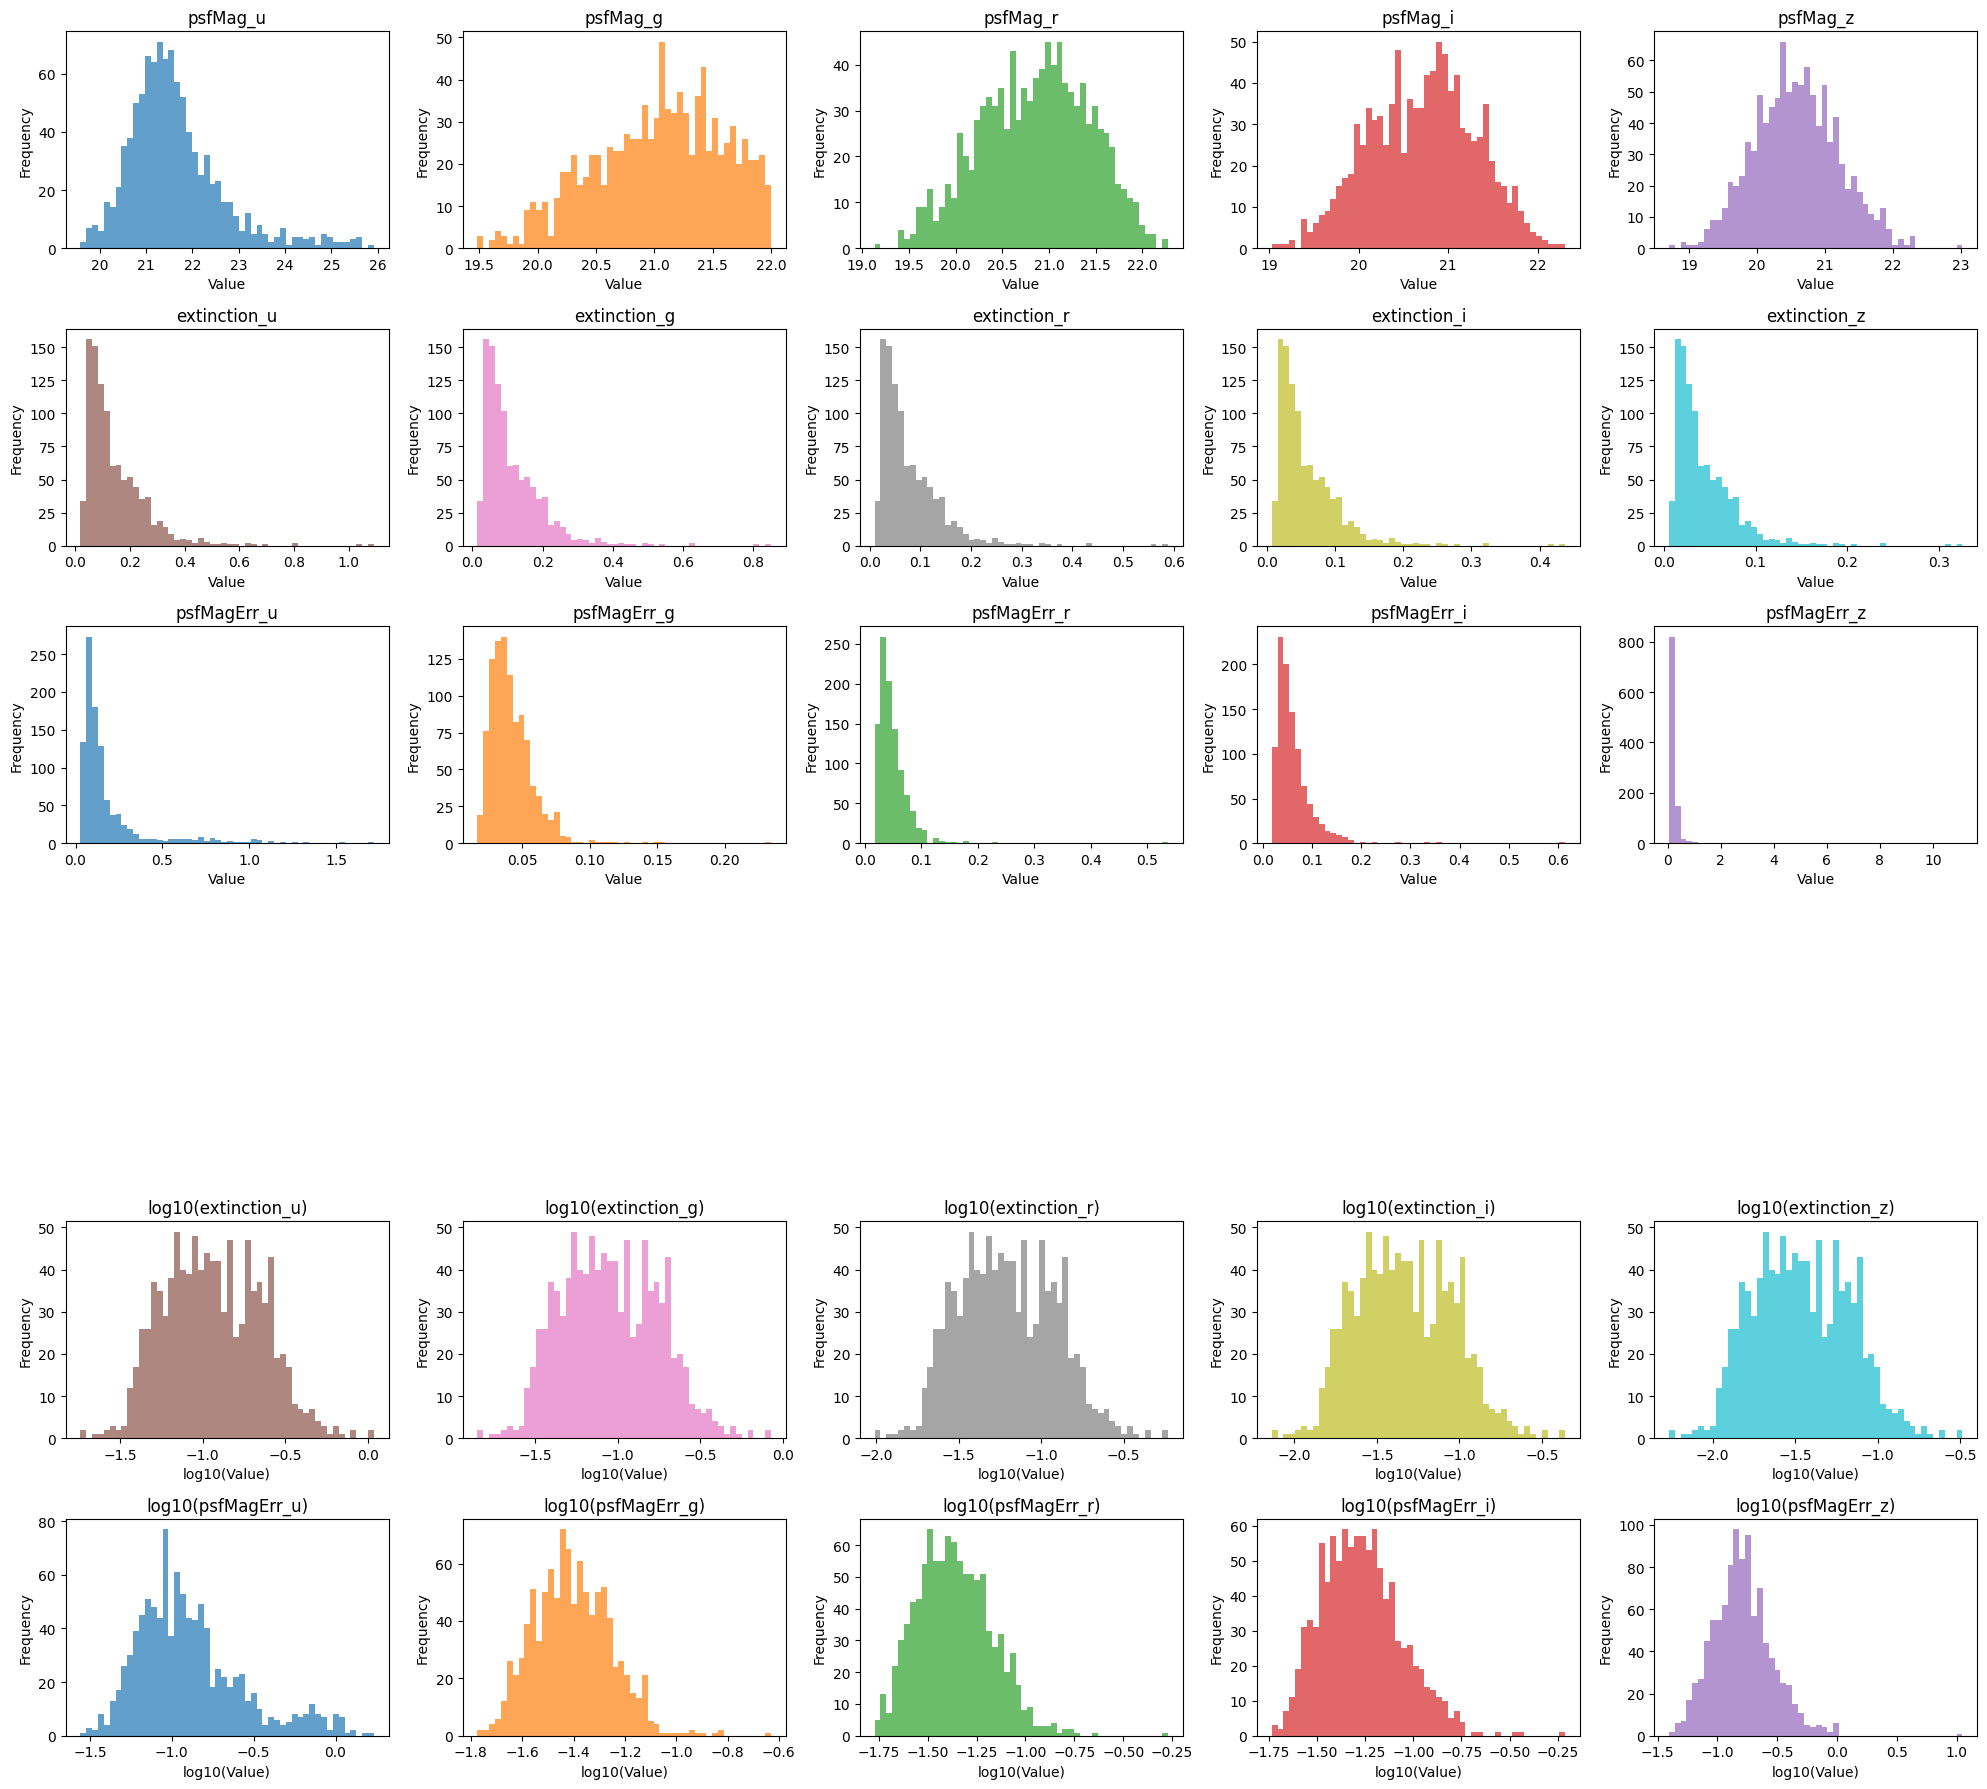

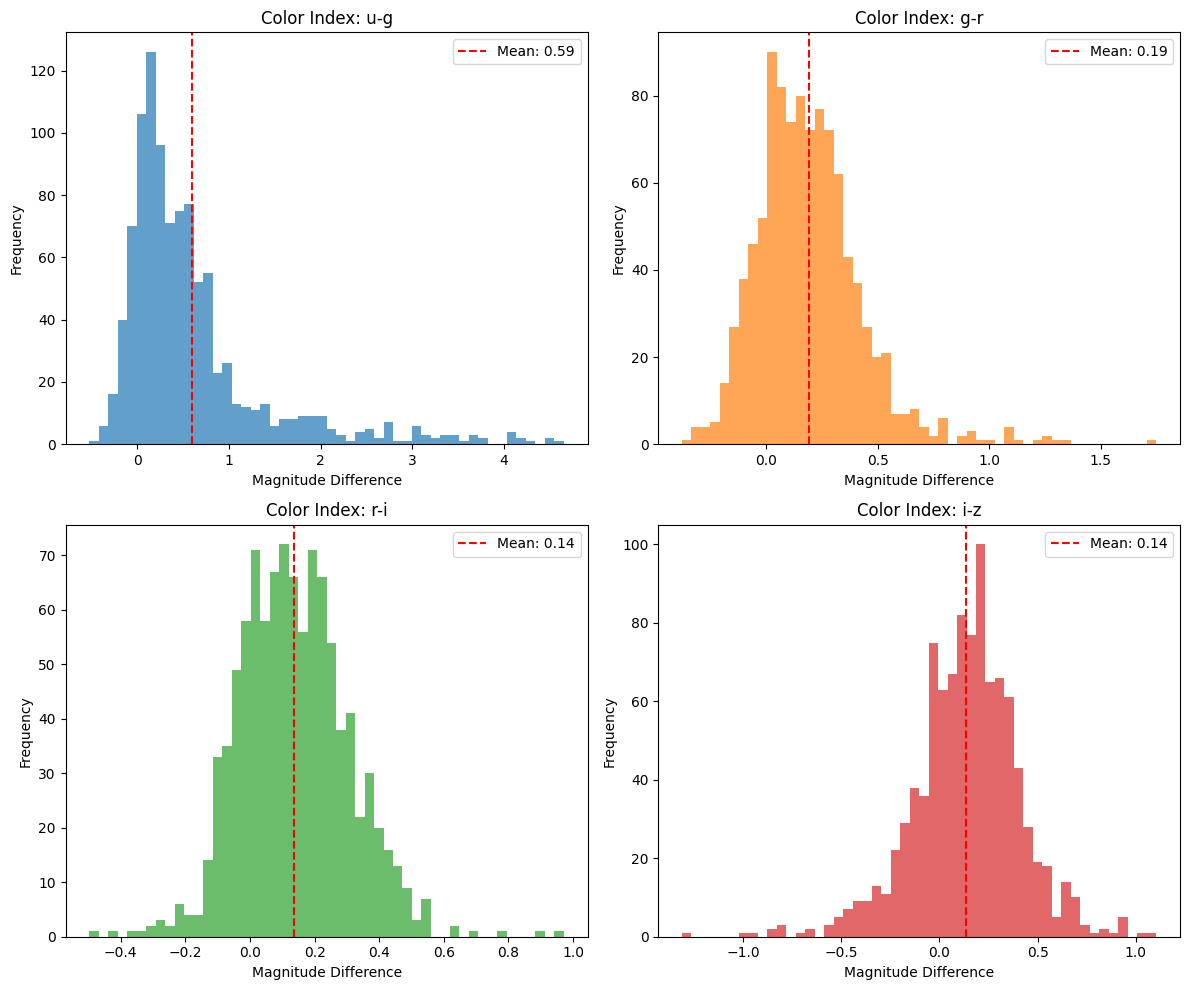

数据集统计信息:
样本数量: 1000
特征数量: 15
psfMag_u: mean=21.635, std=1.035, min=19.585, max=25.917
psfMag_g: mean=21.041, std=0.550, min=19.485, max=21.998
psfMag_r: mean=20.852, std=0.582, min=19.132, max=22.278
psfMag_i: mean=20.714, std=0.589, min=19.025, max=22.311
psfMag_z: mean=20.579, std=0.617, min=18.697, max=23.027
extinction_u: mean=0.146, std=0.112, min=0.018, max=1.093
extinction_g: mean=0.114, std=0.087, min=0.014, max=0.851
extinction_r: mean=0.079, std=0.060, min=0.010, max=0.589
extinction_i: mean=0.058, std=0.045, min=0.007, max=0.438
extinction_z: mean=0.043, std=0.033, min=0.005, max=0.326
psfMagErr_u: mean=0.182, std=0.208, min=0.028, max=1.717
psfMagErr_g: mean=0.042, std=0.017, min=0.017, max=0.234
psfMagErr_r: mean=0.048, std=0.028, min=0.017, max=0.537
psfMagErr_i: mean=0.061, std=0.038, min=0.018, max=0.615
psfMagErr_z: mean=0.202, std=0.370, min=0.039, max=11.118


In [11]:
import numpy as np
params=np.array(params)
visualize_quasar_photometry(params)